# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [ ]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1693,15,67,"(0.0550547819736606, 0.7277451834527079)","(-0.092, -0.23, 0.069, 0.214)",1,1.0,"(-0.097, -0.04, 0.073, 0.034)",0.0,1.0,"(-0.098, -0.231, 0.074, 0.243)"
1031,13,42,"(0.0783299669233051, 0.1772545769968534)","(0.079, 0.244, -0.175, -1.507)",0,1.0,"(0.084, 0.033, -0.205, -0.858)",0.0,1.0,"(0.085, -0.177, -0.222, -0.241)"
1466,44,58,"(0.2286484042312217, 0.8574690262302386)","(-0.106, -1.07, -0.134, 0.34)",1,1.0,"(-0.127, -0.878, -0.127, 0.127)",1.0,1.0,"(-0.145, -0.687, -0.125, -0.085)"
145,29,6,"(0.2451557536988955, 1.3793967951445396)","(-0.042, -0.2, -0.01, 0.04)",0,1.0,"(-0.046, -0.387, -0.009, 0.157)",1.0,1.0,"(-0.054, -0.2, -0.006, 0.038)"
554,3,20,"(0.4182227977310492, 0.0863390757150445)","(-0.028, 0.286, 0.001, -2.374)",0,1.0,"(-0.022, 0.003, -0.046, -0.162)",0.0,1.0,"(-0.022, -0.273, -0.05, 1.932)"
...,...,...,...,...,...,...,...,...,...,...
1768,42,69,"(0.1433033517266329, 1.8075969481187537)","(0.277, 1.105, 0.033, -0.229)",1,1.0,"(0.299, 1.291, 0.028, -0.31)",1.0,1.0,"(0.325, 1.476, 0.022, -0.391)"
196,80,6,"(0.2451557536988955, 1.3793967951445396)","(-0.37, -0.373, -0.036, -0.159)",1,1.0,"(-0.378, -0.185, -0.039, -0.283)",1.0,1.0,"(-0.381, 0.002, -0.045, -0.406)"
1981,0,79,"(0.1768018230473693, 0.6492383504943047)","(0.042, -0.043, 0.042, -0.046)",0,1.0,"(0.041, -0.236, 0.041, 0.203)",1.0,1.0,"(0.036, -0.044, 0.045, -0.025)"
1537,2,63,"(0.5003976278117618, 0.6787717954778089)","(0.012, 0.05, -0.037, -0.019)",1,1.0,"(0.013, 0.246, -0.037, -0.336)",1.0,1.0,"(0.018, 0.443, -0.044, -0.653)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
2185,7,85,"(0.2714262518980411, 0.6857384251475167)","(-0.081, -0.197, 0.04, 0.262)",1,1.0,"(-0.085, -0.004, 0.045, 0.029)",0.0,1.0,"(-0.085, -0.198, 0.046, 0.284)",-0.081,-0.197,0.040,0.262,-0.085,-0.004,0.045,0.029,0.271426,0.685738
227,7,7,"(0.4973847759620192, 0.8507786527021401)","(-0.025, -0.542, 0.081, 0.781)",1,1.0,"(-0.035, -0.351, 0.096, 0.561)",1.0,1.0,"(-0.042, -0.159, 0.108, 0.346)",-0.025,-0.542,0.081,0.781,-0.035,-0.351,0.096,0.561,0.497385,0.850779
142,26,6,"(0.2451557536988955, 1.3793967951445396)","(-0.015, -0.387, -0.022, 0.166)",0,1.0,"(-0.023, -0.574, -0.019, 0.281)",1.0,1.0,"(-0.034, -0.387, -0.013, 0.16)",-0.015,-0.387,-0.022,0.166,-0.023,-0.574,-0.019,0.281,0.245156,1.379397
1291,13,53,"(0.2444473003074412, 0.4846825463128728)","(-0.067, 0.214, 0.04, -0.177)",1,1.0,"(-0.063, 0.41, 0.037, -0.499)",1.0,1.0,"(-0.055, 0.607, 0.027, -0.823)",-0.067,0.214,0.040,-0.177,-0.063,0.410,0.037,-0.499,0.244447,0.484683
971,7,40,"(0.2813661297145153, 1.1191562797649632)","(0.044, 0.206, 0.026, -0.153)",0,1.0,"(0.049, 0.017, 0.023, 0.002)",0.0,1.0,"(0.049, -0.172, 0.023, 0.156)",0.044,0.206,0.026,-0.153,0.049,0.017,0.023,0.002,0.281366,1.119156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1055,23,43,"(0.1333037473628499, 0.2612549147852426)","(-0.081, -0.658, 0.101, 1.512)",1,1.0,"(-0.094, -0.453, 0.131, 1.003)",1.0,1.0,"(-0.103, -0.249, 0.151, 0.515)",-0.081,-0.658,0.101,1.512,-0.094,-0.453,0.131,1.003,0.133304,0.261255
708,18,24,"(0.381115827959413, 0.5947037963670837)","(-0.049, -0.413, 0.079, 0.877)",0,1.0,"(-0.057, -0.61, 0.097, 1.211)",1.0,1.0,"(-0.07, -0.415, 0.121, 0.936)",-0.049,-0.413,0.079,0.877,-0.057,-0.610,0.097,1.211,0.381116,0.594704
1212,5,50,"(0.3156324259991037, 0.4950654122165437)","(0.056, 0.232, -0.032, -0.312)",0,1.0,"(0.06, 0.034, -0.039, 0.026)",0.0,1.0,"(0.061, -0.163, -0.038, 0.362)",0.056,0.232,-0.032,-0.312,0.060,0.034,-0.039,0.026,0.315632,0.495065
1989,8,79,"(0.1768018230473693, 0.6492383504943047)","(0.027, -0.047, 0.051, 0.052)",1,1.0,"(0.026, 0.145, 0.052, -0.173)",0.0,1.0,"(0.029, -0.048, 0.048, 0.078)",0.027,-0.047,0.051,0.052,0.026,0.145,0.052,-0.173,0.176802,0.649238


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
2185,7,85,"(0.2714262518980411, 0.6857384251475167)","(-0.081, -0.197, 0.04, 0.262)",1,1.0,"(-0.085, -0.004, 0.045, 0.029)",0.0,1.0,"(-0.085, -0.198, 0.046, 0.284)",...,-0.197,0.040,0.262,-0.085,-0.004,0.045,0.029,0.271426,0.685738,4.0
227,7,7,"(0.4973847759620192, 0.8507786527021401)","(-0.025, -0.542, 0.081, 0.781)",1,1.0,"(-0.035, -0.351, 0.096, 0.561)",1.0,1.0,"(-0.042, -0.159, 0.108, 0.346)",...,-0.542,0.081,0.781,-0.035,-0.351,0.096,0.561,0.497385,0.850779,0.0
142,26,6,"(0.2451557536988955, 1.3793967951445396)","(-0.015, -0.387, -0.022, 0.166)",0,1.0,"(-0.023, -0.574, -0.019, 0.281)",1.0,1.0,"(-0.034, -0.387, -0.013, 0.16)",...,-0.387,-0.022,0.166,-0.023,-0.574,-0.019,0.281,0.245156,1.379397,1.0
1291,13,53,"(0.2444473003074412, 0.4846825463128728)","(-0.067, 0.214, 0.04, -0.177)",1,1.0,"(-0.063, 0.41, 0.037, -0.499)",1.0,1.0,"(-0.055, 0.607, 0.027, -0.823)",...,0.214,0.040,-0.177,-0.063,0.410,0.037,-0.499,0.244447,0.484683,1.0
971,7,40,"(0.2813661297145153, 1.1191562797649632)","(0.044, 0.206, 0.026, -0.153)",0,1.0,"(0.049, 0.017, 0.023, 0.002)",0.0,1.0,"(0.049, -0.172, 0.023, 0.156)",...,0.206,0.026,-0.153,0.049,0.017,0.023,0.002,0.281366,1.119156,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1055,23,43,"(0.1333037473628499, 0.2612549147852426)","(-0.081, -0.658, 0.101, 1.512)",1,1.0,"(-0.094, -0.453, 0.131, 1.003)",1.0,1.0,"(-0.103, -0.249, 0.151, 0.515)",...,-0.658,0.101,1.512,-0.094,-0.453,0.131,1.003,0.133304,0.261255,0.0
708,18,24,"(0.381115827959413, 0.5947037963670837)","(-0.049, -0.413, 0.079, 0.877)",0,1.0,"(-0.057, -0.61, 0.097, 1.211)",1.0,1.0,"(-0.07, -0.415, 0.121, 0.936)",...,-0.413,0.079,0.877,-0.057,-0.610,0.097,1.211,0.381116,0.594704,0.0
1212,5,50,"(0.3156324259991037, 0.4950654122165437)","(0.056, 0.232, -0.032, -0.312)",0,1.0,"(0.06, 0.034, -0.039, 0.026)",0.0,1.0,"(0.061, -0.163, -0.038, 0.362)",...,0.232,-0.032,-0.312,0.060,0.034,-0.039,0.026,0.315632,0.495065,2.0
1989,8,79,"(0.1768018230473693, 0.6492383504943047)","(0.027, -0.047, 0.051, 0.052)",1,1.0,"(0.026, 0.145, 0.052, -0.173)",0.0,1.0,"(0.029, -0.048, 0.048, 0.078)",...,-0.047,0.051,0.052,0.026,0.145,0.052,-0.173,0.176802,0.649238,3.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.06063053011894226, 0.4277042746543884, 0.28...",1.642115,0.112078
1,1,"[0.05870094522833824, 0.4243529736995697, 0.27...",1.626079,0.113461
2,2,"[0.05681857466697693, 0.4210101068019867, 0.27...",1.610191,0.114866
3,3,"[0.0549837090075016, 0.4176752269268036, 0.266...",1.594452,0.116292
4,4,"[0.05319661647081375, 0.41434794664382935, 0.2...",1.578861,0.117738


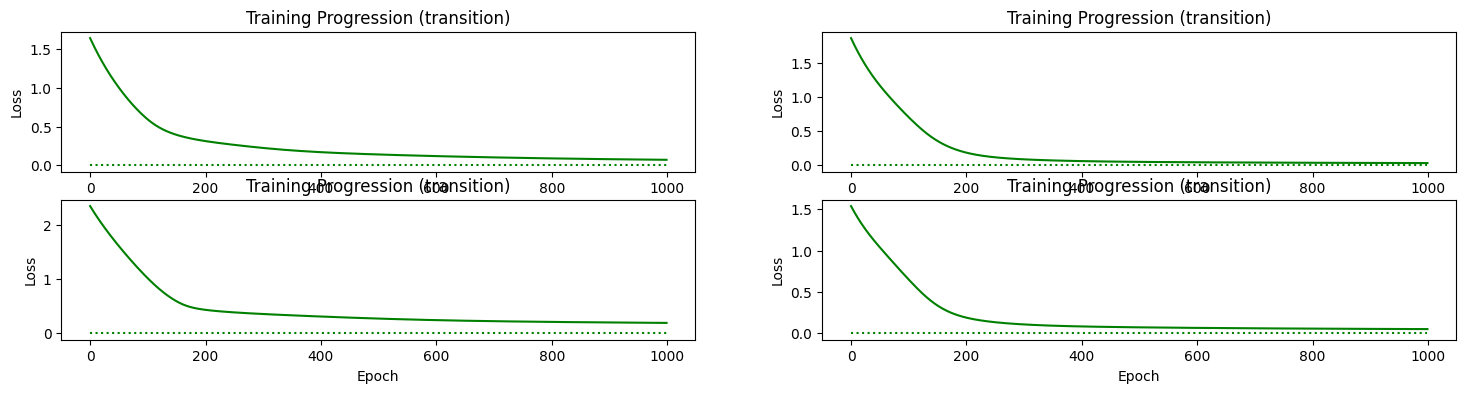

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
2185,7,85,"(0.2714262518980411, 0.6857384251475167)","(-0.081, -0.197, 0.04, 0.262)",1,1.0,"(-0.085, -0.004, 0.045, 0.029)",0.0,1.0,"(-0.085, -0.198, 0.046, 0.284)",...,0.123,0.490795,0.038,0.028,0.019,0.038,0.419234,0.423941,0.544365,0.575639
227,7,7,"(0.4973847759620192, 0.8507786527021401)","(-0.025, -0.542, 0.081, 0.781)",1,1.0,"(-0.035, -0.351, 0.096, 0.561)",1.0,1.0,"(-0.042, -0.159, 0.108, 0.346)",...,0.065,0.481641,0.022,0.013,0.008,0.022,0.412573,0.421328,0.517986,0.574679
142,26,6,"(0.2451557536988955, 1.3793967951445396)","(-0.015, -0.387, -0.022, 0.166)",0,1.0,"(-0.023, -0.574, -0.019, 0.281)",1.0,1.0,"(-0.034, -0.387, -0.013, 0.16)",...,0.190,0.485940,0.038,0.007,0.010,0.135,0.419234,0.420282,0.522782,0.581462
1291,13,53,"(0.2444473003074412, 0.4846825463128728)","(-0.067, 0.214, 0.04, -0.177)",1,1.0,"(-0.063, 0.41, 0.037, -0.499)",1.0,1.0,"(-0.055, 0.607, 0.027, -0.823)",...,0.073,0.482744,0.054,0.009,0.005,0.005,0.425895,0.420631,0.510791,0.573658
971,7,40,"(0.2813661297145153, 1.1191562797649632)","(0.044, 0.206, 0.026, -0.153)",0,1.0,"(0.049, 0.017, 0.023, 0.002)",0.0,1.0,"(0.049, -0.172, 0.023, 0.156)",...,0.167,0.480663,0.022,0.007,0.004,0.134,0.412573,0.420282,0.508393,0.581402


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
4    28
2    28
1    24
3    11
0     9
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.182178
std,0.191808
min,0.015000
25%,0.094000
50%,0.144000
75%,0.219000
max,4.376000


# LOOP

In [13]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1406
best_model
1    33
4    28
2    24
3    12
0     3
Name: count, dtype: int64
best_rse    0.118753
dtype: float64
epis_changed: 1545
best_model
1    38
4    26
2    21
3    11
0     4
Name: count, dtype: int64
best_rse    0.083887
dtype: float64
epis_changed: 1630
best_model
1    40
4    28
2    19
3     9
0     4
Name: count, dtype: int64
best_rse    0.071989
dtype: float64
epis_changed: 1697
best_model
1    43
4    28
2    16
3     9
0     4
Name: count, dtype: int64
best_rse    0.066041
dtype: float64
epis_changed: 1697
best_model
1    46
4    28
2    13
3     9
0     4
Name: count, dtype: int64
best_rse    0.062504
dtype: float64
epis_changed: 1664
best_model
1    46
4    29
2    12
3     9
0     4
Name: count, dtype: int64
best_rse    0.05845
dtype: float64
epis_changed: 1678
best_model
1    42
4    33
2    12
3     9
0     4
Name: count, dtype: int64
best_rse    0.054505
dtype: float64
epis_changed: 1627
best_model
1    39
4    36
2    12
3     9
0     4
Name: c

# Export Model 

In [14]:
import pickle

exp = {
    "data": prediction_dataset,
    "model": models 
}

nome_do_arquivo = 'kmodels.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)